In [1]:
import xarray as xr
import xesmf as xe
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
from pathlib import Path
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

In [2]:
# Target grid (1°)
ds_out = xr.Dataset({
    "lon": (["lon"], np.arange(0, 360, 1)),
    "lat": (["lat"], np.arange(-89.5, 90.5, 1))
})

# Load mask
mask = xr.open_dataset("data/woa_grid.nc")["M3d"].isel(depth=7)

In [3]:
# =========================
# FUNCTION
# =========================
def process_dataset(ncfile, ds_out, M3d, regridder=None):
    """
    Load a POP2 dataset, regrid to 180x360, mask land, and compute phyto limitation.
    
    Parameters
    ----------
    ncfile : str
        Path to POP2 .nc file
    ds_out : xarray.Dataset
        Target grid (lon, lat)
    M3d : np.ndarray
        Land mask (shape ny,nx)
    regridder : xe.Regridder or None
        Pre-built regridder. If None, it will be created.
    
    Returns
    -------
    phyto_lim : np.ndarray
        3D array (ny,nx,3) with limitation codes
    regridder : xe.Regridder
        Regridder object (can reuse for multiple files)
    """
    ds = xr.open_dataset(ncfile)
    
    # Build regridder if not supplied
    if regridder is None:
        ds_in_grid = xr.Dataset({"lat": ds["TLAT"], "lon": ds["TLONG"]})
        regridder = xe.Regridder(ds_in_grid, ds_out, method="nearest_s2d", periodic=True, reuse_weights=False)

    def R(var, mask_var = None):
        """Regrid and mask a variable at the 100m depth slice."""
        da = ds[var]

        # Determine which vertical dimension exists
        if 'z_t' in da.dims:
            zdim = 'z_t'
        elif 'z_t_150m' in da.dims:
            zdim = 'z_t_150m'
        else:
            zdim = None  # variable has no vertical dimension

        # Apply original-grid mask if requested
        if mask_var is not None:
            mask = ds[mask_var]
            da = da.where(mask > 0.1)

        # Take the top slice if vertical dimension exists
        if zdim == 'z_t_150m':
            # Select dz values corresponding to the z_t_150m levels
            dz_top = ds["dz"].sel(z_t=da[zdim])

            # Convert cm to m if needed
            dz_top = dz_top / 100.0

            # Depth integrate over top 150m
            v = (da * dz_top).sum(dim=zdim).values

        elif zdim == 'z_t':
            # For variables already on full depth grid
            #da_top = da.where(da[zdim] <= 15000, drop=True)
            dz_top = ds["dz"].sel(z_t=da[zdim]) / 100.0
            v = (da * dz_top).sum(dim=zdim).values

        else:
            v = da.values  # no vertical dimension

        # Regrid
        v = regridder(v)

        # Mask inland/land
        v[v == 0] = np.nan
        v = v[0, :, :]  
        v[M3d.T[:,:] == 0] = np.nan  # transpose mask if needed

        return v
    
    # Unpack POC data
    nfix = R("diaz_Nfix")
    denitrif = R("DENITRIF")
    
    return nfix, denitrif

In [4]:
# =========================
# MAIN
# =========================
files = [
    "data/gdev1440.pop.h.0281_0300.nc",
    "data/gdev1420.pop.h.0281_0300.nc"
]

nfix_int = None
denitrif_int = None

for i, f in enumerate(files):
    name = Path(f).stem
    nfix, denitrif = process_dataset(f, ds_out, mask)
    if nfix_int is None:
        ny, nx = nfix.shape
        nfix_int = np.full((ny, nx, len(files)), np.nan)
        denitrif_int = np.full((ny, nx, len(files)), np.nan)
    nfix_int[:,:,i] = nfix
    denitrif_int[:,:,i] = denitrif
print("All datasets processed.")

nfix_change = ((nfix_int[:,:,1] - nfix_int[:,:,0])/nfix_int[:,:,0])*100
denitrif_change = ((denitrif_int[:,:,1] - denitrif_int[:,:,0])/denitrif_int[:,:,0])*100

/tmp/ipykernel_1784544/3707387394.py:26: FutureWarning: In a future version, xarray will not decode the variable 'days_in_norm_year' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(ncfile)
/tmp/ipykernel_1784544/3707387394.py:26: FutureWarning: In a future version, xarray will not decode the variable 'days_in_norm_year' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta

All datasets processed.


In [5]:
mpl.rcParams.update({
    "text.usetex": False,      # LaTeX usually ends up as paths
    "svg.fonttype": "none",    # keep SVG text as <text>
    "pdf.fonttype": 42,        # embed TrueType, keeps text editable in PDF
    "ps.fonttype": 42,
    # optional, for consistent glyphs:
    "mathtext.fontset": "stix",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"]
})
plt.rcParams['font.family'] = 'sans-serif'  # e.g., 'Arial', 'Helvetica', 'Times New Roman'

# Use absolute font sizes for all text elements
plt.rcParams.update({
    'font.size': 9,  # Base font size in points
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})


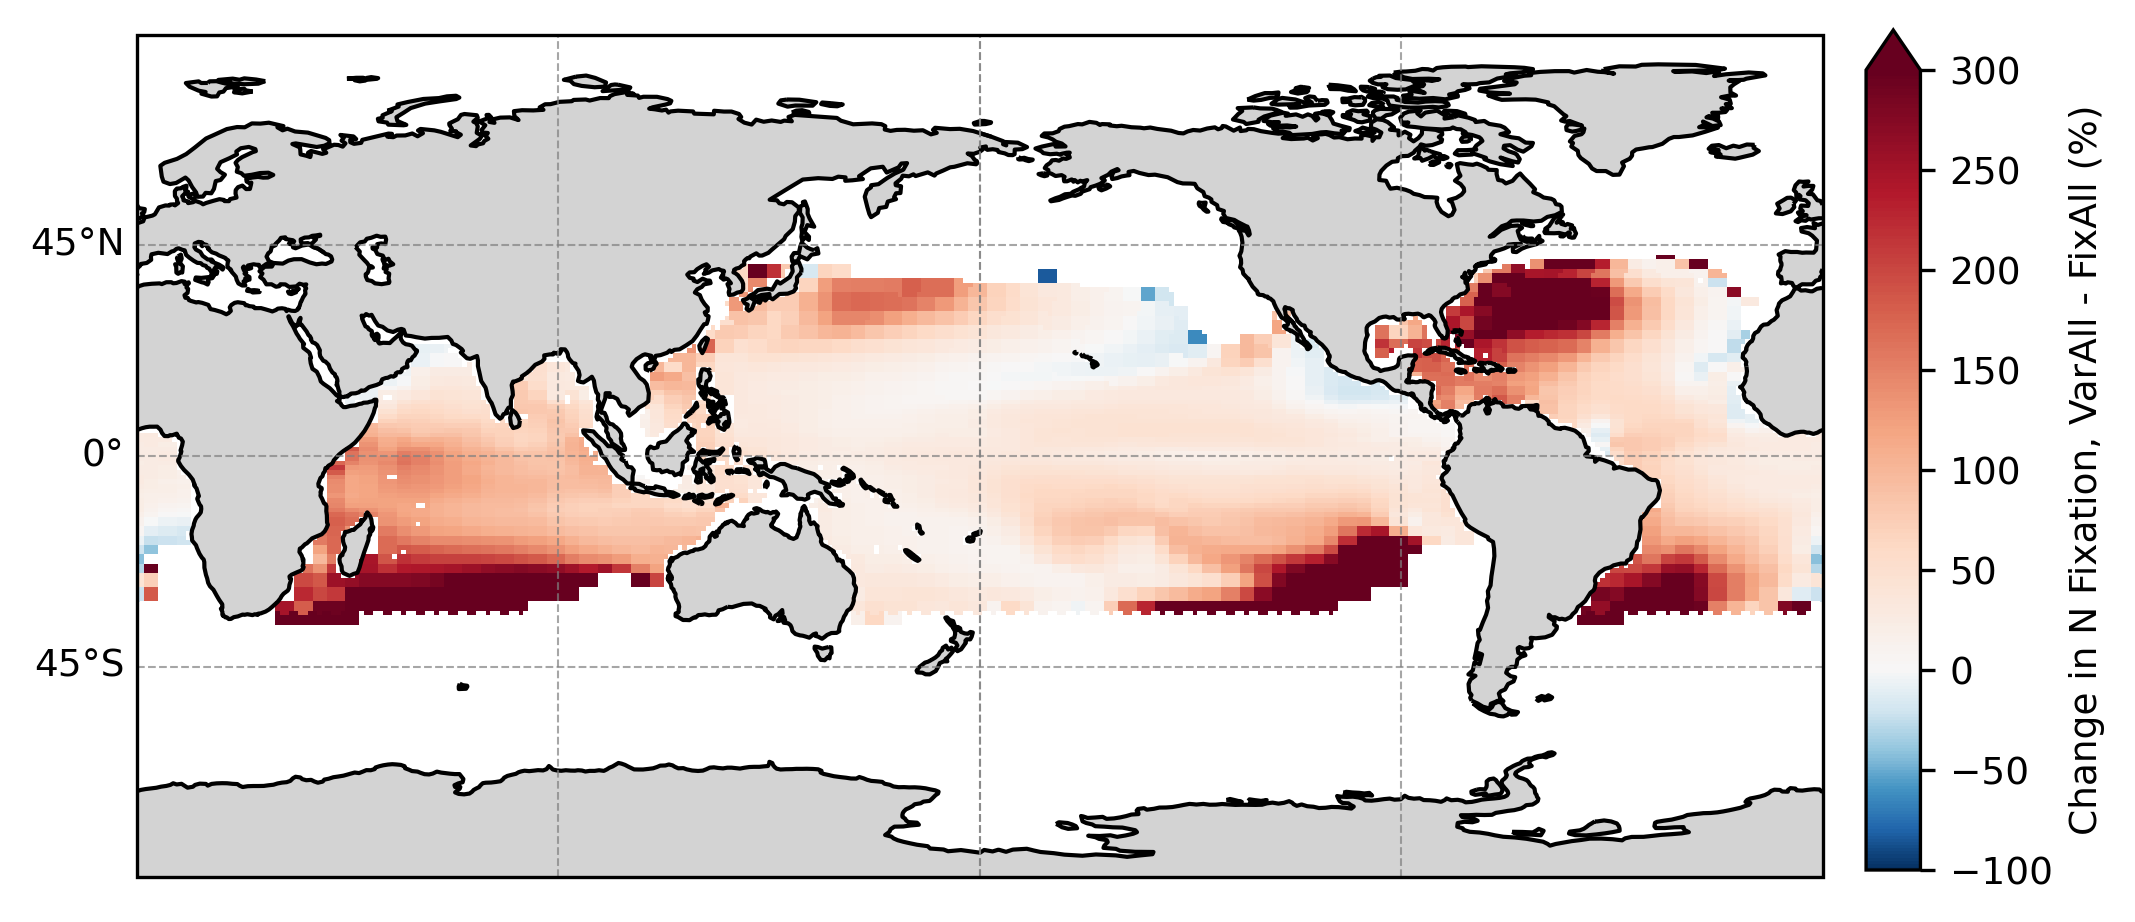

In [ ]:
fig = plt.figure(figsize=(7.25, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-180))
ax.add_feature(cart.feature.LAND, facecolor='lightgray', zorder=0)
ax.set_global()
ax.coastlines(zorder=2)

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.xlocator = ticker.FixedLocator([-180, -90, 0, 90, 180])
gl.ylocator = ticker.FixedLocator([-90, -45, 0, 45, 90])
gl.top_labels = False            # Select top 150 m
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = True
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}
gl.xformatter = LongitudeFormatter(zero_direction_label=False, degree_symbol='°')
gl.yformatter = LatitudeFormatter(degree_symbol='°')

norm = TwoSlopeNorm(
    vmin=-100,
    vcenter=0,
    vmax=300
)

mesh = ax.pcolormesh(
    ds_out["lon"], ds_out["lat"], nfix_change,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.RdBu.reversed(),
    norm = norm,
    zorder=1
)

# Original colormap
cmap_orig = plt.cm.RdBu_r

# New color positions:
# blue -> white happens at 1/6, then white -> red spans 5/6
colors = cmap_orig(np.linspace(0, 1, 256))

# Build a new lookup table with the midpoint shifted
new_positions = np.concatenate([
    np.linspace(0, 0.5, 64),     # blue to white compressed
    np.linspace(0.5, 1, 192)     # white to red expanded
])

new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "RdBu_shifted",
    list(zip(np.linspace(0, 1, 256), cmap_orig(new_positions)))
)

cax = fig.add_axes([0.92, 0.15, 0.025, 0.7])

cbar = ColorbarBase(
    cax,
    cmap=new_cmap,
    norm=mcolors.Normalize(vmin=-100, vmax=300),%% Calculate Fluxes for all runs
% Calculate NPP, POC export, PON export, POP export,
% nitrogen fixation, and watercolumn denitrification
% for all runs

clearvars; close all

addpath ../data/
addpath ../utils/
file1 = ('/home/mv23682/Documents/MATLAB/data/gdev1420.pop.h.0281_0300.nc'); %varAll
file2 = ('/home/mv23682/Documents/MATLAB/data/gdev1440.pop.h.0281_0300.nc'); %fixAll
file3 = ('/home/mv23682/Documents/MATLAB/data/gdev1441.pop.h.0281_0300.nc'); %varN
file4 = ('/home/mv23682/Documents/MATLAB/data/gdev1442.pop.h.0281_0300.nc'); %fixN
file5 = ('/home/mv23682/Documents/MATLAB/data/gdev1443.pop.h.0281_0300.nc'); %varP
file6 = ('/home/mv23682/Documents/MATLAB/data/gdev1444.pop.h.0281_0300.nc'); %fixP
file7 = ('/home/mv23682/Documents/MATLAB/data/gdev1445.pop.h.0281_0300.nc'); %varFe
file8 = ('/home/mv23682/Documents/MATLAB/data/gdev1446.pop.h.0281_0300.nc'); %fixFe
file9 = ('/home/mv23682/Documents/MATLAB/data/gdev1447.pop.h.0281_0300.nc'); %varSi
file10 = ('/home/mv23682/Documents/MATLAB/data/gdev1448.pop.h.0281_0300.nc'); %fixSi
files = {file2,file3,file5,file7,file9,file1,file4,file6,file8,file10};
% General Variables
lat = ncread(file1,'TLAT');
lon = ncread(file1,'TLONG');
tarea = ncread(file1,'TAREA').*0.0001; % convert to meters
depth = ncread(file1,'z_t').*1e-2; % convert to meters
depth_150m = ncread(file1,'z_t_150m').*1e-2; % convert to meters
vol = reshape(tarea,[size(tarea, 1), size(tarea, 2), 1]) .* reshape(depth,[1, 1, size(depth, 1)]);

% Establish matrices for efficiency
NPP = NaN([100 116 15 length(files)]);
NPP_100m = NaN([100 116 length(files)]);
Nfix = NaN([100 116 length(files)]);
WCdenit = NaN([100 116 length(files)]);
POC_100m = NaN([100 116 length(files)]);
Fe_scavenge_100m = NaN([100 116 length(files)]);
Fe_uptake_100m = NaN([100 116 length(files)]);
PON_100m = NaN([100 116 length(files)]);
POP_100m = NaN([100 116 length(files)]);
P_iron_100m = NaN([100 116 length(files)]);
SiO2_100m = NaN([100 116 length(files)]);
NPP_tot = NaN([length(files),1]);
POC_tot = NaN([length(files),1]);
PON_tot = NaN([length(files),1]);
POP_tot = NaN([length(files),1]);
P_iron_tot = NaN([length(files),1]);
SiO2_tot = NaN([length(files),1]);
Nfix_tot = NaN([length(files),1]);
Denit_tot = NaN([length(files),1]);
spC_tot = NaN([length(files),1]);
diatC_tot = NaN([length(files),1]);
diazC_tot = NaN([length(files),1]);
biomass_tot = NaN([length(files),1]);

% 
for i = 1:length(files)
    % Unpack data
    
    % Carbon Fixation
    photoC_sp = ncread(files{i},'photoC_sp'); % units mmol/m3/s
    photoC_diat = ncread(files{i},'photoC_diat'); % units mmol/m3/s
    photoC_diaz = ncread(files{i},'photoC_diaz'); % units mmol/m3/s
    NPP = photoC_sp + photoC_diat + photoC_diaz; % units mmol/m3/s
    NPP_100m(:,:,i) = sum(NPP(:,:,1:11),3); % Integrate over top 100m
    
    % Biomass
    spC = ncread(files{i},'spC'); % mmol/m3
    diatC = ncread(files{i},'diatC'); % mmol/m3
    diazC = ncread(files{i},'diazC'); % mmol/m3
    biomass = spC + diatC + diazC; % units mmol/m3


    % Particulate Pool
    POC_FLUX_IN = ncread(files{i},'POC_FLUX_IN'); % units nmol/m2 cm/s; level 10
    POC_100m(:,:,i) = POC_FLUX_IN(:,:,depth==105);
    PON_FLUX_IN = ncread(files{i},'PON_FLUX_IN'); % units nmol/m2 cm/s; level 10
    PON_100m(:,:,i) = PON_FLUX_IN(:,:,depth==105);
    POP_FLUX_IN = ncread(files{i},'POP_FLUX_IN'); % units nmol/m2 cm/s; level 10
    POP_100m(:,:,i) = POP_FLUX_IN(:,:,depth==105);
    SiO2_FLUX_IN = ncread(files{i},'SiO2_FLUX_IN'); % units
    SiO2_100m(:,:,i) = SiO2_FLUX_IN(:,:,depth==105);
    P_iron_FLUX_IN = ncread(files{i},'P_iron_FLUX_IN');
    P_iron_100m(:,:,i) = P_iron_FLUX_IN(:,:,depth==105);

    % Nitrogen Cycle
    diaz_Nfix = ncread(files{i},'diaz_Nfix'); % units mmol/m3/s
    diaz_Nfix(diaz_Nfix<=0) = NaN;
    Nfix(:,:,i) = sum(diaz_Nfix(:,:,:),3,'omitnan'); % Integrate over all depths 
    DENITRIF = ncread(files{i},'DENITRIF'); % units mmol/m3/s
    WCdenit(:,:,i) = sum(DENITRIF(:,:,:),3,'omitnan'); % Integrate over all depths

    % Integrate globally
    NPP_tot(i) = sum(tarea.*NPP_100m(:,:,i),'all','omitnan')*(12.01*10.0*365.25*24*60*60)*1e-3*1e-15; % convert to PgC/yr
    POC_tot(i) = sum(tarea.*POC_100m(:,:,i),'all','omitnan')*(12.01*10.0*365.25*24*60*60)*1e-6*1e-15; % convert to PgC/yr
    PON_tot(i) = sum(tarea.*PON_100m(:,:,i),'all','omitnan')*(14.01*10.0*365.25*24*60*60)*1e-6*1e-15; % convert to PgN/yr
    POP_tot(i) = sum(tarea.*POP_100m(:,:,i),'all','omitnan')*(30.97*10.0*365.25*24*60*60)*1e-6*1e-12; % convert to TgP/yr
    P_iron_tot(i) = sum(tarea.*P_iron_100m(:,:,i),'all','omitnan')*(10.0*365.25*24*60*60)*1e-3*1e-12; % convert to TmolFe/yr
    SiO2_tot(i) = sum(tarea.*SiO2_100m(:,:,i),'all','omitnan')*(10.0*365.25*24*60*60)*1e-6*1e-12; % convert to TmolSi/yr
    Nfix_tot(i) = sum(tarea.*Nfix(:,:,i),'all','omitnan')*(14.01*10.0*365.25*24*60*60)*1e-3*1e-12; % convert to TgN/yr
    Denit_tot(i) = sum(tarea.*WCdenit(:,:,i),'all','omitnan')*(14.01*10.0*365.25*24*60*60)*1e-3*1e-12; % convert to TgN/yr
    spC_tot(i) = sum(tarea.*spC(:,:,1:10),'all','omitnan')*(12.01*10.0)*1e-3*1e-12; % convert to TgC
    diatC_tot(i) = sum(tarea.*diatC(:,:,1:10),'all','omitnan')*(12.01*10.0)*1e-3*1e-12; % convert to TgC
    diazC_tot(i) = sum(tarea.*diazC(:,:,1:10),'all','omitnan')*(12.01*10.0)*1e-3*1e-12; % convert to TgC
    biomass_tot(i) = sum(tarea.*biomass(:,:,1:10),'all','omitnan')*(12.01*10.0)*1e-3*1e-12; % convert to TgC


    clear photoC_sp photoC_diat photoC_diaz NPP diaz_Nfix DENITRIF biomass ...
        spC diatC diazC POC_FLUX_IN PON_FLUX_IN POP_FLUX_IN
end

CN_export = (POC_tot./12.01)./(PON_tot./14.01);
CP_export = (POC_tot./12.01)./(POP_tot*1e-3./30.97);
NP_export = (PON_tot./14.01)./(POP_tot*1e-3./30.97);
FeC_export = (P_iron_tot)./(PON_tot./14.01);
SiN_export = (SiO2_tot./1e3)./(PON_tot./14.01);
fracsp = spC_tot./biomass_tot;
fracdiat = diatC_tot./biomass_tot;
fracdiaz = diazC_tot./biomass_tot;
    orientation="vertical",
    extend='max'
)

cbar.set_ticks([-100, -50, 0, 50, 100, 150, 200, 250, 300])
cbar.set_label("Change in N Fixation, VarAll - FixAll (%)")

ax.set_rasterization_zorder(1)
filename = f"figures/nfix_change.svg"
plt.savefig(filename, dpi=600, bbox_inches='tight',
        transparent=False)

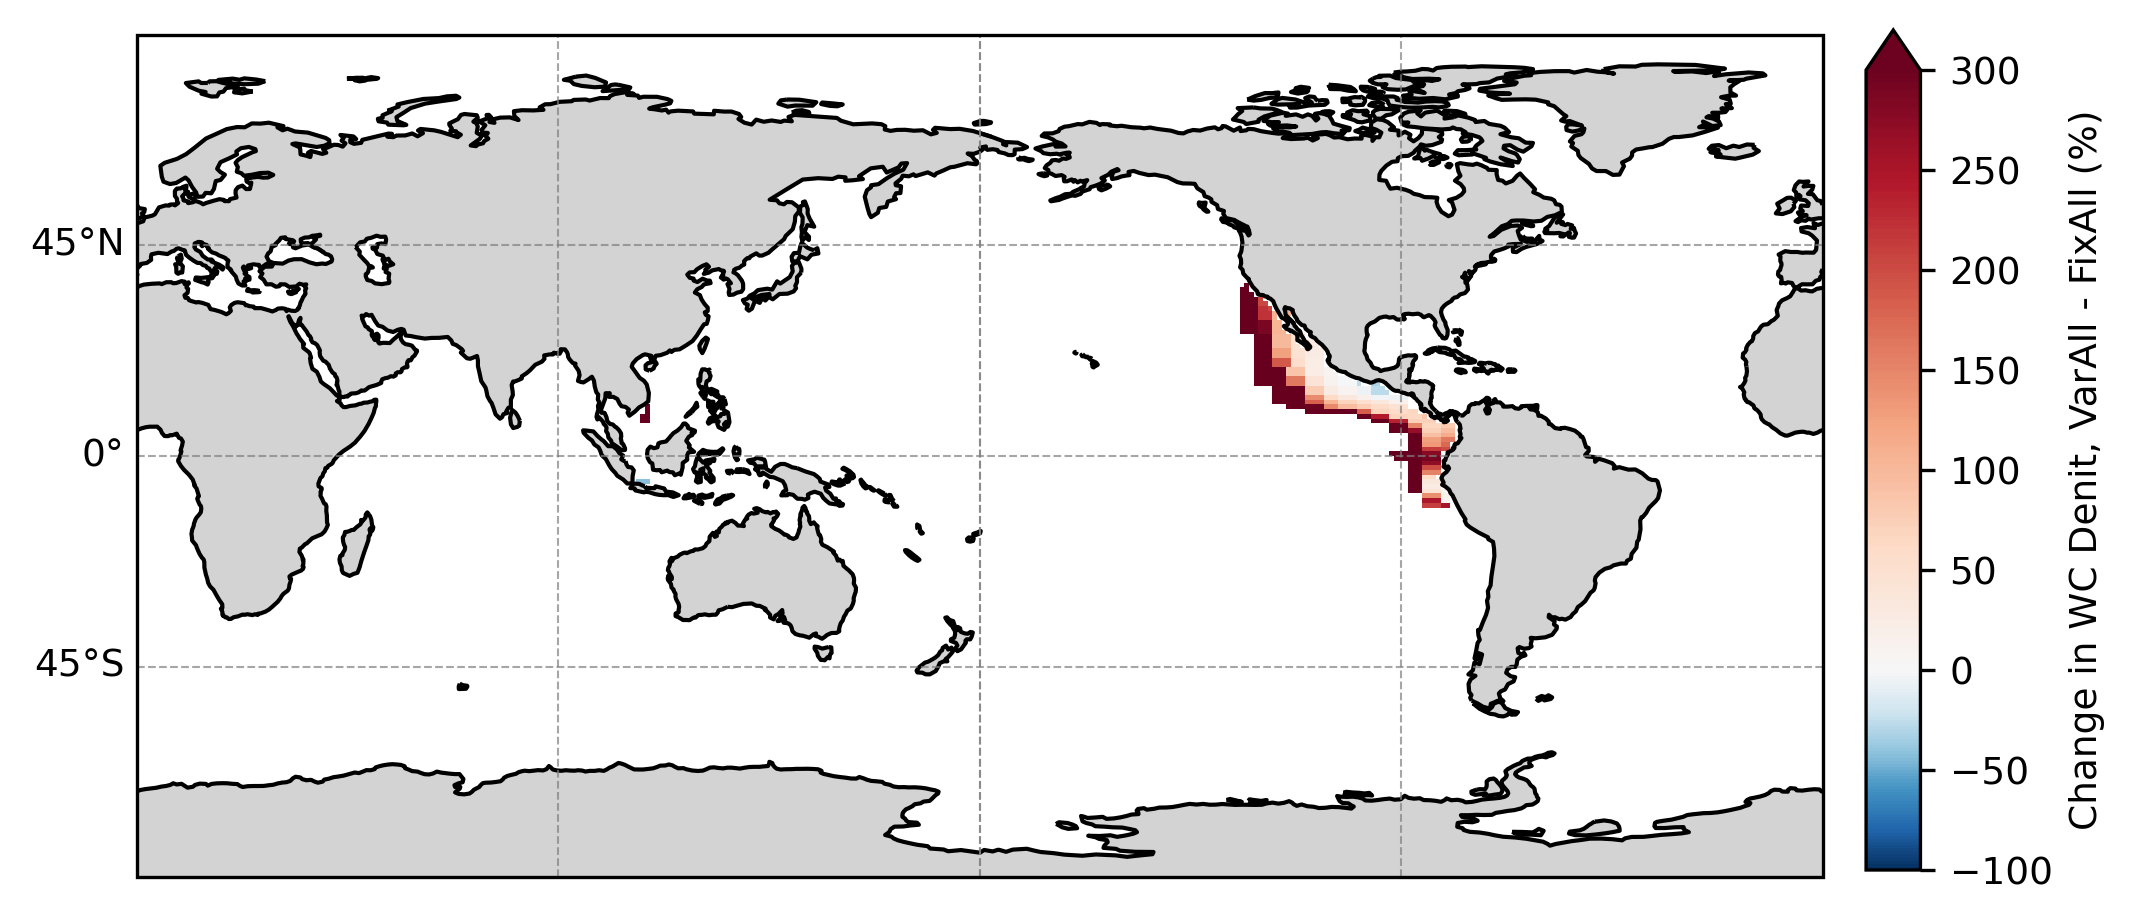

In [12]:
fig = plt.figure(figsize=(7.25, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-180))
ax.add_feature(cart.feature.LAND, facecolor='lightgray', zorder=0)
ax.set_global()
ax.coastlines(zorder=2)

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.xlocator = ticker.FixedLocator([-180, -90, 0, 90, 180])
gl.ylocator = ticker.FixedLocator([-90, -45, 0, 45, 90])
gl.top_labels = False            # Select top 150 m
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = True
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}
gl.xformatter = LongitudeFormatter(zero_direction_label=False, degree_symbol='°')
gl.yformatter = LatitudeFormatter(degree_symbol='°')

norm = TwoSlopeNorm(
    vmin=-100,
    vcenter=0,
    vmax=300
)

mesh = ax.pcolormesh(
    ds_out["lon"], ds_out["lat"], denitrif_change,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.RdBu.reversed(),
    norm = norm,
    zorder=1
)

# Original colormap
cmap_orig = plt.cm.RdBu_r

# New color positions:
# blue -> white happens at 1/6, then white -> red spans 5/6
colors = cmap_orig(np.linspace(0, 1, 256))

# Build a new lookup table with the midpoint shifted
new_positions = np.concatenate([
    np.linspace(0, 0.5, 64),     # blue to white compressed
    np.linspace(0.5, 1, 196)     # white to red expanded
])

new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "RdBu_shifted",
    list(zip(np.linspace(0, 1, 256), cmap_orig(new_positions)))
)

cax = fig.add_axes([0.92, 0.15, 0.025, 0.7])

cbar = ColorbarBase(
    cax,
    cmap=new_cmap,
    norm=mcolors.Normalize(vmin=-100, vmax=300),
    orientation="vertical",
    extend='max'
)

cbar.set_ticks([-100, -50, 0, 50, 100, 150, 200, 250, 300])
cbar.set_label("Change in WC Denit, VarAll - FixAll (%)")

ax.set_rasterization_zorder(1)
filename = f"figures/denitrif_change.svg"
plt.savefig(filename, dpi=600, bbox_inches='tight',
        transparent=False)

In [ ]:
fig = plt.figure(figsize=(7.25, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-180))
ax.add_feature(cart.feature.LAND, facecolor='lightgray', zorder=0)
ax.set_global(), 400, 500, 600, 700, 800, 900, 1000
ax.coastlines(zorder=2)

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.xlocator = ticker.FixedLocator([-180, -90, 0, 90, 180])        # Apply original-grid mask if requested
gl.ylocator = ticker.FixedLocator([-90, -45, 0, 45, 90])
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = True
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}
gl.xformatter = LongitudeFormatter(zero_direction_label=False, degree_symbol='°')
gl.yformatter = LatitudeFormatter(degree_symbol='°')

mesh = ax.pcolormesh(
    ds_out["lon"], ds_out["lat"], diazC_change,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.RdBu.reversed(),
    vmin=-100,
    vmax=100,
    zorder=1
)

cax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
cbar = ColorbarBase(
    cax,
    cmap=plt.cm.RdBu.reversed(),
    norm=mcolors.Normalize(vmin=-100, vmax=100),
    orientation="vertical",
    extend='max'
)

cbar.set_ticks([-100, -75, -50, -25, 0, 25, 50, 75, 100])
cbar.set_label("Change in diatC Biomass, VarAll - FixAll (%)")
cbar.set_label("Change in diazC Biomass, VarAll - FixAll (%)")

ax.set_rasterization_zorder(1)
filename = f"figures/diazC_change.svg"
plt.savefig(filename, dpi=600, bbox_inches='tight',
        transparent=False)